**##Scalable HPC-Based Spatio-Temporal Energy Demand Forecasting with CPU–GPU Hybrid Parallelism**

**Install Required Libraries**

In [ ]:
# Install required packages
!pip install gradio xgboost plotly scikit-learn numba

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import time

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBRegressor

from numba import njit, prange

import gradio as gr

**Upload Dataset**

In [ ]:
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

df.head()

Saving energy_data.csv to energy_data.csv


,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
0,2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
1,2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2,2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
3,2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
4,2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


**Data Preprocessing**

In [ ]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

df = df.sort_values("DateTime")
# Remove missing values
df = df.dropna()
df.reset_index(drop=True, inplace=True)

df.head()

,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
0,2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
1,2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2,2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
3,2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
4,2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


**Feature Engineering**

In [ ]:
df["hour"] = df["DateTime"].dt.hour
df["day_of_week"] = df["DateTime"].dt.dayofweek

# Lag features
df["lag1"] = df["Consumption"].shift(1)
df["lag2"] = df["Consumption"].shift(2)

# Rolling mean
df["rolling_mean"] = df["Consumption"].rolling(5).mean()

df = df.dropna()

df.head()

,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,hour,day_of_week,lag1,lag2,rolling_mean
4,2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30,4,1,5682.0,5873.0,5916.0
5,2019-01-01 05:00:00,5525,5385,1395,91,958,1455,1456,0,30,5,1,5557.0,5682.0,5750.6
6,2019-01-01 06:00:00,5513,5349,1392,98,938,1451,1440,0,31,6,1,5525.0,5557.0,5630.0
7,2019-01-01 07:00:00,5524,5547,1392,93,1187,1446,1394,0,34,7,1,5513.0,5525.0,5560.2
8,2019-01-01 08:00:00,5510,5471,1391,51,1325,1357,1303,8,34,8,1,5524.0,5513.0,5525.8


**HPC Sliding Window**

In [ ]:
@njit(parallel=True)
def create_windows(data, window_size):

    X = []
    y = []

    for i in prange(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])

    return np.array(X), np.array(y)

**Prepare Training Data**

In [ ]:
features = ["Consumption","lag1","lag2","rolling_mean","hour","day_of_week"]

X = df[features]
y = df["Consumption"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

**Model 1 – Linear Regression**

In [ ]:
start = time.time()

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_time = time.time() - start

lr_pred = lr_model.predict(X_test)

**Model 2 – XGBoost (Parallel CPU)**

In [ ]:
start = time.time()

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_time = time.time() - start

xgb_pred = xgb_model.predict(X_test)

**Model Evaluation**

In [ ]:
def evaluate(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2


lr_metrics = evaluate(y_test, lr_pred)
xgb_metrics = evaluate(y_test, xgb_pred)

print("Linear Regression:", lr_metrics)
print("XGBoost:", xgb_metrics)

Linear Regression: (1.9737675716589196e-13, np.float64(4.23636836451023e-13), 1.0)
XGBoost: (6.6000823974609375, np.float64(17.135948078607566), 0.9996646046638489)


**HPC Performance Comparison**

In [ ]:
print("Execution Time")

print("Linear Regression:", lr_time)
print("XGBoost Parallel:", xgb_time)

speedup = lr_time / xgb_time

print("Speedup:", speedup)

Execution Time
Linear Regression: 0.03874993324279785
XGBoost Parallel: 1.0777239799499512
Speedup: 0.03595534103694842


**Peak Demand ML Classification**

In [ ]:
threshold = df["Consumption"].quantile(0.9)

df["peak"] = (df["Consumption"] > threshold).astype(int)

X_class = df[features]
y_class = df["peak"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, shuffle=False
)

classifier = RandomForestClassifier()

classifier.fit(X_train_c, y_train_c)

RandomForestClassifier()

In [ ]:
peak_prob = classifier.predict_proba(X_test_c)[:,1]

**Visualization Charts**

Energy trend

In [ ]:
fig = px.line(df, x="DateTime", y="Consumption", title="Energy Consumption Trend")

fig.show()

Prediction vs Actual

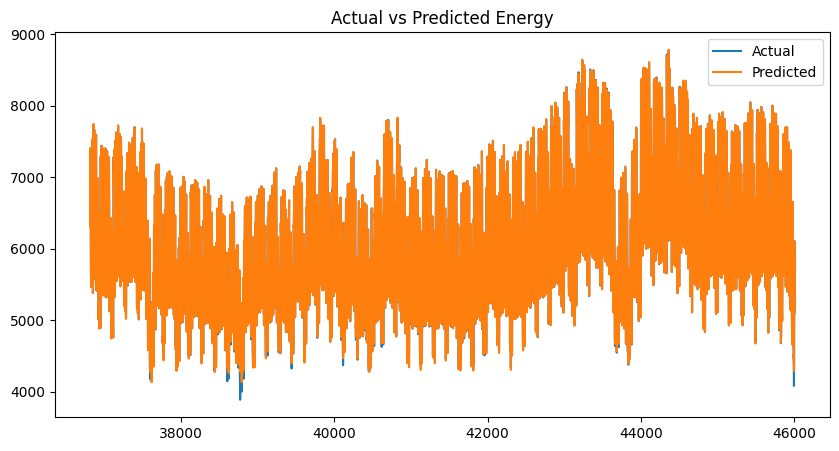

In [ ]:
result_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": xgb_pred
})

result_df.plot(figsize=(10,5))

plt.title("Actual vs Predicted Energy")

plt.show()

**Output CSV Generation**

In [ ]:
output = X_test.copy()

output["actual_energy"] = y_test.values
output["predicted_energy"] = xgb_pred
peak_prob = classifier.predict_proba(X_test_c)[:,1] # Moved calculation here
output["peak_probability"] = peak_prob

output.to_csv("energy_predictions.csv", index=False)

output.head()

,Consumption,lag1,lag2,rolling_mean,hour,day_of_week,actual_energy,predicted_energy,peak_probability
36809,6363,6487.0,6609.0,6643.8,13,1,6363,6368.563965,0.0
36810,6313,6363.0,6487.0,6511.0,14,1,6313,6309.797852,0.0
36811,6324,6313.0,6363.0,6419.2,15,1,6324,6320.749512,0.0
36812,6374,6324.0,6313.0,6372.2,16,1,6374,6368.343262,0.0
36813,6578,6374.0,6324.0,6390.4,17,1,6578,6575.997559,0.0


In [ ]:
files.download("energy_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Gradio Interface**

**Real-Time Simulation**

In [ ]:
import time

for i in range(10):

    sample = X_test.iloc[i:i+1]

    pred = xgb_model.predict(sample)

    print("Predicted Demand:", pred[0])

    time.sleep(1)

Predicted Demand: 6368.564
Predicted Demand: 6309.798
Predicted Demand: 6320.7495
Predicted Demand: 6368.3433
Predicted Demand: 6575.9976
Predicted Demand: 6970.3804
Predicted Demand: 7400.358
Predicted Demand: 7388.2354
Predicted Demand: 7156.335
Predicted Demand: 6417.488


**Final Dashboard Chart**

In [ ]:
fig = px.scatter(
    output,
    x="predicted_energy",
    y="peak_probability",
    title="Peak Demand Risk"
)

fig.show()

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
import gradio as gr

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd
import gradio as gr
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**Train Anomaly Detection Model**

In [ ]:
# Anomaly Detection Model

anomaly_model = IsolationForest(
    contamination=0.02,
    random_state=42
)

anomaly_model.fit(X_train)

IsolationForest(contamination=0.02, random_state=42)

**Real-Time Energy Simulation Function**

In [ ]:
def simulate_realtime():

    values = np.random.normal(500, 50, 50)

    df = pd.DataFrame({
        "time": range(50),
        "energy": values
    })

    fig = px.line(
        df,
        x="time",
        y="energy",
        title="Real-Time Energy Consumption Simulation"
    )

    return fig

**Main Prediction Dashboard Function**

In [ ]:
def predict_file(file):

    try:

        df = pd.read_csv(file)

        df.columns = df.columns.str.strip()

        if "Consumption" not in df.columns:
            if "energy" in df.columns:
                df.rename(columns={"energy":"Consumption"}, inplace=True)

        if "datetime" not in df.columns:
            df["datetime"] = pd.date_range(
                start="2024-01-01",
                periods=len(df),
                freq="H"
            )

        df["datetime"] = pd.to_datetime(df["datetime"])

        # Feature Engineering
        df["hour"] = df["datetime"].dt.hour
        df["day_of_week"] = df["datetime"].dt.dayofweek

        df["lag1"] = df["Consumption"].shift(1)
        df["lag2"] = df["Consumption"].shift(2)

        df["rolling_mean"] = df["Consumption"].rolling(5).mean()

        df = df.dropna()

        features = ["Consumption","lag1","lag2","rolling_mean","hour","day_of_week"]

        X = df[features]

        preds = xgb_model.predict(X)

        peak_prob = classifier.predict_proba(X)[:,1]

        df["predicted_energy"] = preds
        df["peak_probability"] = peak_prob

        anomaly_scores = anomaly_model.predict(X)

        df["anomaly"] = anomaly_scores
        df["anomaly"] = df["anomaly"].map({1:"Normal",-1:"Anomaly"})

        # KPI Metrics
        current_demand = round(df["Consumption"].iloc[-1],2)
        predicted_demand = round(df["predicted_energy"].iloc[-1],2)

        peak_risk = round(df["peak_probability"].iloc[-1]*100,2)

        anomaly_count = (df["anomaly"]=="Anomaly").sum()

        # Charts
        fig1 = px.line(df, x="datetime", y="Consumption",
                       title="Energy Consumption Trend")

        fig2 = go.Figure()

        fig2.add_trace(go.Scatter(
            x=df["datetime"], y=df["Consumption"], name="Actual"))

        fig2.add_trace(go.Scatter(
            x=df["datetime"], y=df["predicted_energy"], name="Predicted"))

        fig2.update_layout(title="Actual vs Predicted Energy")

        heatmap = px.density_heatmap(
            df, x="hour", y="day_of_week", z="Consumption",
            title="Peak Demand Heatmap")

        anomaly_chart = px.scatter(
            df, x="datetime", y="Consumption",
            color="anomaly", title="Energy Anomaly Detection")

        df.to_csv("prediction_output.csv", index=False)

        return (
            current_demand,
            predicted_demand,
            peak_risk,
            anomaly_count,
            df.head(20),
            fig1,
            fig2,
            heatmap,
            anomaly_chart,
            "prediction_output.csv"
        )

    except Exception as e:

        return None,None,None,None,pd.DataFrame({"Error":[str(e)]}),None,None,None,None,None

In [ ]:
with gr.Blocks(title="AI Energy Intelligence Platform") as dashboard:

    gr.Markdown("# ⚡ AI Energy Intelligence Platform")

    gr.Markdown("Upload energy dataset to predict demand, detect peak loads, and monitor anomalies.")

    file_input = gr.File(label="Upload Energy CSV")

    # Add the demo dataset button here, inside the gr.Blocks context
    demo_button = gr.Button("Generate Demo Dataset")

    with gr.Row():

        current_card = gr.Number(label="⚡ Current Demand")

        predicted_card = gr.Number(label="📈 Predicted Demand")

        peak_card = gr.Number(label="⚠️ Peak Risk (%)")

        anomaly_card = gr.Number(label="🚨 Anomaly Alerts")

    result_table = gr.Dataframe(label="Prediction Results")

    # Connect the demo_button to the run_demo function (updated from generate_demo_dataset)
    demo_button.click(
        fn=run_demo,
        inputs=None,
        outputs=result_table
    )

    with gr.Row():

        chart1 = gr.Plot(label="Energy Consumption Trend")

        chart2 = gr.Plot(label="Prediction vs Actual")

    with gr.Row():

        chart3 = gr.Plot(label="Peak Demand Heatmap")

        chart4 = gr.Plot(label="Anomaly Detection")

    download_file = gr.File(label="Download Prediction CSV")

    run_button = gr.Button("Run AI Forecast")

    run_button.click(
        predict_file,
        inputs=file_input,
        outputs=[
            current_card,
            predicted_card,
            peak_card,
            anomaly_card,
            result_table,
            chart1,
            chart2,
            chart3,
            chart4,
            download_file
        ]
    )

dashboard.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c667d5477c21f783f6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
future_steps = 24

future_preds=[]

last_data=X_test.iloc[-1:]

for i in range(future_steps):

    pred=xgb_model.predict(last_data)[0]

    future_preds.append(pred)

    last_data["Consumption"]=pred

/tmp/ipykernel_497/2216266020.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_497/2216266020.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_497/2216266020.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_497/

**Smart Grid Control Logic**

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

def smart_grid_simulation():

    demand = []
    supply = []
    status = []

    base = 500

    for i in range(50):

        # simulate demand fluctuation
        d = base + np.random.normal(0,40)

        demand.append(d)

        # AI control logic
        if d > 560:
            supply.append(580)
            status.append("Peak Control Activated")

        elif d < 450:
            supply.append(460)
            status.append("Low Demand")

        else:
            supply.append(520)
            status.append("Normal")

    df = pd.DataFrame({
        "time": range(50),
        "demand": demand,
        "supply": supply,
        "status": status
    })

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=df["time"],
        y=df["demand"],
        name="Energy Demand"
    ))

    fig.add_trace(go.Scatter(
        x=df["time"],
        y=df["supply"],
        name="Grid Supply"
    ))

    fig.update_layout(
        title="Smart Grid AI Control Simulation",
        xaxis_title="Time",
        yaxis_title="Energy Level"
    )

    return df, fig

In [ ]:
smart_grid = gr.Interface(
    fn=smart_grid_simulation,
    inputs=None,
    outputs=[
        gr.Dataframe(label="Smart Grid Status"),
        gr.Plot(label="Demand vs Supply Control")
    ],
    title="⚡ Smart Grid AI Control Simulation",
    description="AI automatically adjusts energy supply based on predicted demand."
)

In [ ]:
app = gr.TabbedInterface(
    [dashboard, smart_grid],
    ["Energy Forecasting Platform", "Smart Grid Control"]
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f8c28781b9d05275c1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


**Synthetic Energy Dataset Generator**

In [ ]:
import numpy as np
import pandas as pd

def generate_demo_dataset():

    np.random.seed(42)

    hours = 500

    base_load = 500

    data = []

    for i in range(hours):

        # daily pattern
        hour_of_day = i % 24

        if 18 <= hour_of_day <= 22:
            demand = base_load + 120 + np.random.normal(0,20)
        elif 0 <= hour_of_day <= 5:
            demand = base_load - 80 + np.random.normal(0,15)
        else:
            demand = base_load + np.random.normal(0,25)

        data.append(demand)

    df = pd.DataFrame({
        "Consumption": data
    })

    return df

In [ ]:
def run_demo():

    df = generate_demo_dataset()

    df["datetime"] = pd.date_range(
        start="2024-01-01",
        periods=len(df),
        freq="H"
    )

    df["hour"] = df["datetime"].dt.hour
    df["day_of_week"] = df["datetime"].dt.dayofweek

    df["lag1"] = df["Consumption"].shift(1)
    df["lag2"] = df["Consumption"].shift(2)

    df["rolling_mean"] = df["Consumption"].rolling(5).mean()

    df = df.dropna()

    features=["Consumption","lag1","lag2","rolling_mean","hour","day_of_week"]

    X=df[features]

    preds=xgb_model.predict(X)

    df["predicted_energy"]=preds

    return df.head(20)

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go


#############################################
# DEMO DATASET GENERATOR
#############################################

def generate_demo_dataset():

    np.random.seed(42)

    hours = 200
    base_load = 500
    data = []

    for i in range(hours):

        hour_of_day = i % 24

        if 18 <= hour_of_day <= 22:
            demand = base_load + 120 + np.random.normal(0,20)

        elif 0 <= hour_of_day <= 5:
            demand = base_load - 80 + np.random.normal(0,15)

        else:
            demand = base_load + np.random.normal(0,25)

        data.append(demand)

    df = pd.DataFrame({"Consumption":data})

    return df


#############################################
# MAIN AI PREDICTION FUNCTION
#############################################

def run_ai_pipeline(df):

    df["datetime"] = pd.date_range(
        start="2024-01-01",
        periods=len(df),
        freq="H"
    )

    df["hour"] = df["datetime"].dt.hour
    df["day_of_week"] = df["datetime"].dt.dayofweek

    df["lag1"] = df["Consumption"].shift(1)
    df["lag2"] = df["Consumption"].shift(2)

    df["rolling_mean"] = df["Consumption"].rolling(5).mean()

    df = df.dropna()

    features = [
        "Consumption",
        "lag1",
        "lag2",
        "rolling_mean",
        "hour",
        "day_of_week"
    ]

    X = df[features]

    preds = xgb_model.predict(X)

    peak_prob = classifier.predict_proba(X)[:,1]

    anomaly_scores = anomaly_model.predict(X)

    df["predicted_energy"] = preds
    df["peak_probability"] = peak_prob
    df["anomaly"] = anomaly_scores
    df["anomaly"] = df["anomaly"].map({1:"Normal",-1:"Anomaly"})


    #########################################
    # KPI VALUES
    #########################################

    current_demand = round(df["Consumption"].iloc[-1],2)

    predicted_demand = round(df["predicted_energy"].iloc[-1],2)

    peak_risk = round(df["peak_probability"].iloc[-1]*100,2)

    anomaly_count = (df["anomaly"]=="Anomaly").sum()


    #########################################
    # CHARTS
    #########################################

    energy_chart = px.line(
        df,
        x="datetime",
        y="Consumption",
        title="Energy Consumption Trend"
    )


    pred_chart = go.Figure()

    pred_chart.add_trace(go.Scatter(
        x=df["datetime"],
        y=df["Consumption"],
        name="Actual"
    ))

    pred_chart.add_trace(go.Scatter(
        x=df["datetime"],
        y=df["predicted_energy"],
        name="Predicted"
    ))

    pred_chart.update_layout(
        title="Actual vs Predicted Energy"
    )


    heatmap = px.density_heatmap(
        df,
        x="hour",
        y="day_of_week",
        z="Consumption",
        title="Peak Demand Heatmap"
    )


    anomaly_chart = px.scatter(
        df,
        x="datetime",
        y="Consumption",
        color="anomaly",
        title="Energy Anomaly Detection"
    )


    df.to_csv("prediction_output.csv",index=False)


    return (
        current_demand,
        predicted_demand,
        peak_risk,
        anomaly_count,
        df.head(20),
        energy_chart,
        pred_chart,
        heatmap,
        anomaly_chart,
        "prediction_output.csv"
    )


#############################################
# FILE UPLOAD HANDLER
#############################################

def predict_file(file):

    df = pd.read_csv(file)

    if "Consumption" not in df.columns:

        if "energy" in df.columns:
            df.rename(columns={"energy":"Consumption"},inplace=True)

    return run_ai_pipeline(df)


#############################################
# DEMO DATASET HANDLER
#############################################

def run_demo():

    df = generate_demo_dataset()

    return run_ai_pipeline(df)


#############################################
# SMART GRID SIMULATION
#############################################

def smart_grid_simulation():

    demand=[]
    supply=[]

    base=500

    for i in range(50):

        d = base + np.random.normal(0,40)

        demand.append(d)

        if d > 560:
            supply.append(580)

        elif d < 450:
            supply.append(460)

        else:
            supply.append(520)

    df = pd.DataFrame({
        "time":range(50),
        "demand":demand,
        "supply":supply
    })

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=df["time"],
        y=df["demand"],
        name="Demand"
    ))

    fig.add_trace(go.Scatter(
        x=df["time"],
        y=df["supply"],
        name="Grid Supply"
    ))

    fig.update_layout(
        title="Smart Grid Control Simulation"
    )

    return df,fig


#############################################
# DASHBOARD UI
#############################################

with gr.Blocks(
    theme=gr.themes.Soft(),
    title="AI Energy Intelligence Platform"
) as dashboard:


    gr.Markdown("# ⚡ AI Energy Intelligence Platform")

    gr.Markdown(
    "AI system for forecasting electricity demand, detecting peak loads, and monitoring anomalies."
    )


    file_input = gr.File(label="Upload Energy CSV")

    run_button = gr.Button("Run AI Forecast")

    demo_button = gr.Button("Generate Demo Dataset")


    with gr.Row():

        current_card = gr.Number(label="⚡ Current Demand")

        predicted_card = gr.Number(label="📈 Predicted Demand")

        peak_card = gr.Number(label="⚠️ Peak Risk (%)")

        anomaly_card = gr.Number(label="🚨 Anomaly Alerts")


    result_table = gr.Dataframe(label="Prediction Results")


    gr.Markdown("## 📊 Energy Analytics")

    with gr.Row():

        chart1 = gr.Plot(label="Energy Consumption")

        chart2 = gr.Plot(label="Prediction vs Actual")


    gr.Markdown("## ⚡ Risk Monitoring")

    with gr.Row():

        chart3 = gr.Plot(label="Peak Demand Heatmap")

        chart4 = gr.Plot(label="Anomaly Detection")


    download_file = gr.File(label="Download Prediction CSV")


    run_button.click(
        predict_file,
        inputs=file_input,
        outputs=[
            current_card,
            predicted_card,
            peak_card,
            anomaly_card,
            result_table,
            chart1,
            chart2,
            chart3,
            chart4,
            download_file
        ]
    )


    demo_button.click(
        run_demo,
        inputs=None,
        outputs=[
            current_card,
            predicted_card,
            peak_card,
            anomaly_card,
            result_table,
            chart1,
            chart2,
            chart3,
            chart4,
            download_file
        ]
    )


#############################################
# SMART GRID TAB
#############################################

smart_grid = gr.Interface(
    fn=smart_grid_simulation,
    inputs=None,
    outputs=[
        gr.Dataframe(label="Grid Status"),
        gr.Plot(label="Demand vs Supply")
    ],
    title="Smart Grid Control Simulation"
)


#############################################
# MULTI TAB APP
#############################################

app = gr.TabbedInterface(
    [dashboard, smart_grid],
    ["Energy Forecasting Platform","Smart Grid Simulation"]
)


app.launch(share=True)

/tmp/ipykernel_497/250389520.py:248: DeprecationWarning:

The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.



Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7aee36280dc0f7991e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


**Feature Importance Graph**

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

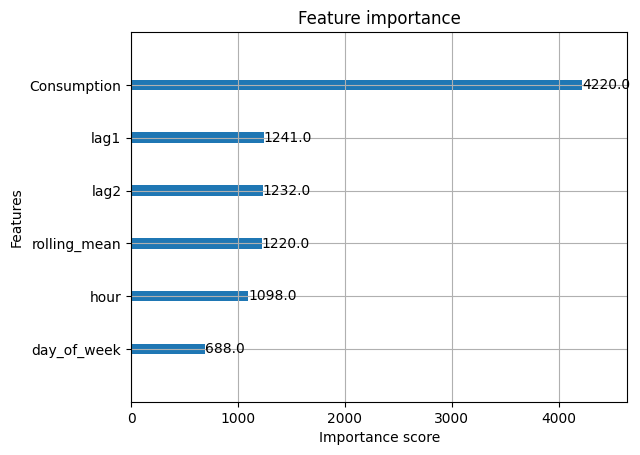

In [ ]:
from xgboost import plot_importance
plot_importance(xgb_model)

**Model Comparison Chart (Linear Regression vs XGBoost)**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import plotly.express as px

# Linear Regression prediction
lr_pred = lr_model.predict(X_test)

# XGBoost prediction
xgb_pred = xgb_model.predict(X_test)

# Metrics
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

lr_mae = mean_absolute_error(y_test, lr_pred)
xgb_mae = mean_absolute_error(y_test, xgb_pred)

lr_r2 = r2_score(y_test, lr_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

# Create comparison table
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost"],
    "RMSE": [lr_rmse, xgb_rmse],
    "MAE": [lr_mae, xgb_mae],
    "R2 Score": [lr_r2, xgb_r2]
})

comparison_df

,Model,RMSE,MAE,R2 Score
0,Linear Regression,4.236368e-13,1.973768e-13,1.000000
1,XGBoost,1.713595e+01,6.600082e+00,0.999665


In [ ]:
fig_model = px.bar(
    comparison_df,
    x="Model",
    y="RMSE",
    color="Model",
    title="Model Performance Comparison (RMSE)"
)

fig_model.show()

**24-Hour Future Forecast Graph**

In [ ]:
def forecast_future(hours=24):

    future_data = X_test.iloc[-1:].copy()

    predictions = []

    for i in range(hours):

        pred = xgb_model.predict(future_data)[0]

        predictions.append(pred)

        future_data["Consumption"] = pred
        future_data["lag1"] = pred
        future_data["lag2"] = future_data["lag1"]

    future_df = pd.DataFrame({
        "Hour": range(1, hours+1),
        "Predicted Consumption": predictions
    })

    return future_df

In [ ]:
future_df = forecast_future(24)

fig_future = px.line(
    future_df,
    x="Hour",
    y="Predicted Consumption",
    title="24-Hour Energy Demand Forecast"
)

fig_future.show()

**GRADIO DASHBOARD**

In [ ]:
 import gradio as gr
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


###############################################
# DEMO DATASET GENERATOR
###############################################

def generate_demo_dataset():

    np.random.seed(42)

    hours = 200
    base = 500
    data = []

    for i in range(hours):

        hour = i % 24

        if 18 <= hour <= 22:
            demand = base + 120 + np.random.normal(0,20)

        elif 0 <= hour <= 5:
            demand = base - 80 + np.random.normal(0,15)

        else:
            demand = base + np.random.normal(0,25)

        data.append(demand)

    df = pd.DataFrame({"Consumption":data})

    return df


###############################################
# MODEL COMPARISON CHART
###############################################

def model_comparison_chart():

    lr_pred = lr_model.predict(X_test)
    xgb_pred = xgb_model.predict(X_test)

    lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

    lr_mae = mean_absolute_error(y_test, lr_pred)
    xgb_mae = mean_absolute_error(y_test, xgb_pred)

    lr_r2 = r2_score(y_test, lr_pred)
    xgb_r2 = r2_score(y_test, xgb_pred)

    comparison_df = pd.DataFrame({
        "Model":["Linear Regression","XGBoost"],
        "RMSE":[lr_rmse,xgb_rmse],
        "MAE":[lr_mae,xgb_mae],
        "R2":[lr_r2,xgb_r2]
    })

    fig = px.bar(
        comparison_df,
        x="Model",
        y="RMSE",
        color="Model",
        title="Model Performance Comparison"
    )

    return fig


###############################################
# 24 HOUR FORECAST
###############################################

def forecast_future(hours=24):

    future_data = X_test.iloc[-1:].copy()

    predictions=[]

    for i in range(hours):

        pred = xgb_model.predict(future_data)[0]

        predictions.append(pred)

        future_data["Consumption"]=pred
        future_data["lag1"]=pred
        future_data["lag2"]=future_data["lag1"]

    future_df = pd.DataFrame({
        "Hour":range(1,hours+1),
        "Predicted Consumption":predictions
    })

    fig = px.line(
        future_df,
        x="Hour",
        y="Predicted Consumption",
        title="24 Hour Energy Forecast"
    )

    return fig


###############################################
# AI PIPELINE
###############################################

def run_ai_pipeline(df):

    df["datetime"] = pd.date_range(
        start="2024-01-01",
        periods=len(df),
        freq="H"
    )

    df["hour"] = df["datetime"].dt.hour
    df["day_of_week"] = df["datetime"].dt.dayofweek

    df["lag1"] = df["Consumption"].shift(1)
    df["lag2"] = df["Consumption"].shift(2)

    df["rolling_mean"] = df["Consumption"].rolling(5).mean()

    df = df.dropna()

    features=[
        "Consumption",
        "lag1",
        "lag2",
        "rolling_mean",
        "hour",
        "day_of_week"
    ]

    X = df[features]

    preds = xgb_model.predict(X)

    peak_prob = classifier.predict_proba(X)[:,1]

    anomaly_scores = anomaly_model.predict(X)

    df["predicted_energy"]=preds
    df["peak_probability"]=peak_prob
    df["anomaly"]=anomaly_scores
    df["anomaly"]=df["anomaly"].map({1:"Normal",-1:"Anomaly"})


    ##################################
    # KPI METRICS
    ##################################

    current_demand = round(df["Consumption"].iloc[-1],2)
    predicted_demand = round(df["predicted_energy"].iloc[-1],2)
    peak_risk = round(df["peak_probability"].iloc[-1]*100,2)
    anomaly_count = (df["anomaly"]=="Anomaly").sum()


    ##################################
    # CHARTS
    ##################################

    energy_chart = px.line(
        df,
        x="datetime",
        y="Consumption",
        title="Energy Consumption Trend"
    )

    pred_chart = go.Figure()

    pred_chart.add_trace(go.Scatter(
        x=df["datetime"],
        y=df["Consumption"],
        name="Actual"
    ))

    pred_chart.add_trace(go.Scatter(
        x=df["datetime"],
        y=df["predicted_energy"],
        name="Predicted"
    ))

    pred_chart.update_layout(title="Actual vs Predicted Energy")


    heatmap = px.density_heatmap(
        df,
        x="hour",
        y="day_of_week",
        z="Consumption",
        title="Peak Demand Heatmap"
    )


    anomaly_chart = px.scatter(
        df,
        x="datetime",
        y="Consumption",
        color="anomaly",
        title="Anomaly Detection"
    )


    ##################################
    # ADDITIONAL CHARTS
    ##################################

    model_chart = model_comparison_chart()

    forecast_chart = forecast_future()


    df.to_csv("prediction_output.csv",index=False)


    return (
        current_demand,
        predicted_demand,
        peak_risk,
        anomaly_count,
        df.head(20),
        energy_chart,
        pred_chart,
        heatmap,
        anomaly_chart,
        model_chart,
        forecast_chart,
        "prediction_output.csv"
    )


###############################################
# FILE INPUT
###############################################

def predict_file(file):

    if file is None:

        df = generate_demo_dataset()

    else:

        df = pd.read_csv(file)

        if "Consumption" not in df.columns:
            if "energy" in df.columns:
                df.rename(columns={"energy":"Consumption"},inplace=True)

    return run_ai_pipeline(df)


###############################################
# DEMO DATA BUTTON
###############################################

def run_demo():

    df = generate_demo_dataset()

    return run_ai_pipeline(df)


###############################################
# SMART GRID SIMULATION
###############################################

def smart_grid_simulation():

    demand=[]
    supply=[]

    base=500

    for i in range(50):

        d = base + np.random.normal(0,40)

        demand.append(d)

        if d>560:
            supply.append(580)

        elif d<450:
            supply.append(460)

        else:
            supply.append(520)

    df = pd.DataFrame({
        "time":range(50),
        "demand":demand,
        "supply":supply
    })

    fig = go.Figure()

    fig.add_trace(go.Scatter(x=df["time"],y=df["demand"],name="Demand"))
    fig.add_trace(go.Scatter(x=df["time"],y=df["supply"],name="Supply"))

    fig.update_layout(title="Smart Grid Control Simulation")

    return df,fig


###############################################
# DASHBOARD UI
###############################################

with gr.Blocks(theme=gr.themes.Soft()) as dashboard:

    gr.Markdown("# ⚡ AI Energy Intelligence Platform")

    file_input = gr.File(label="Upload Energy Dataset")

    run_button = gr.Button("Run AI Forecast")
    demo_button = gr.Button("Generate Demo Dataset")


    with gr.Row():

        current_card = gr.Number(label="⚡ Current Demand")
        predicted_card = gr.Number(label="📈 Predicted Demand")
        peak_card = gr.Number(label="⚠ Peak Risk (%)")
        anomaly_card = gr.Number(label="🚨 Anomaly Alerts")


    result_table = gr.Dataframe(label="Prediction Results")


    gr.Markdown("## Energy Analytics")

    with gr.Row():
        chart1 = gr.Plot()
        chart2 = gr.Plot()

    with gr.Row():
        chart3 = gr.Plot()
        chart4 = gr.Plot()


    gr.Markdown("## Model Insights")

    with gr.Row():
        chart5 = gr.Plot()
        chart6 = gr.Plot()


    download_file = gr.File(label="Download Results")


    run_button.click(
        predict_file,
        inputs=file_input,
        outputs=[
            current_card,
            predicted_card,
            peak_card,
            anomaly_card,
            result_table,
            chart1,
            chart2,
            chart3,
            chart4,
            chart5,
            chart6,
            download_file
        ]
    )


    demo_button.click(
        run_demo,
        inputs=None,
        outputs=[
            current_card,
            predicted_card,
            peak_card,
            anomaly_card,
            result_table,
            chart1,
            chart2,
            chart3,
            chart4,
            chart5,
            chart6,
            download_file
        ]
    )


###############################################
# SMART GRID TAB
###############################################

smart_grid = gr.Interface(
    fn=smart_grid_simulation,
    inputs=None,
    outputs=[
        gr.Dataframe(),
        gr.Plot()
    ],
    title="Smart Grid Simulation"
)


###############################################
# MULTI TAB APP
###############################################

app = gr.TabbedInterface(
    [dashboard, smart_grid],
    ["Energy Forecast Dashboard","Smart Grid Control"]
)

app.launch(share=True)

/tmp/ipykernel_497/883707754.py:319: DeprecationWarning:

The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.



Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a173eac4f7cf9e3cee.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import os

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ✅ STEP 1: MOUNT GOOGLE DRIVE
from google.colab import drive
drive.mount('/content/drive')

# ✅ STEP 2: CREATE FOLDER IN DRIVE
folder_path = "/content/drive/MyDrive/Energy_Project"
os.makedirs(folder_path, exist_ok=True)


###############################################
# DEMO DATASET GENERATOR
###############################################
def generate_demo_dataset():
    np.random.seed(42)
    hours = 200
    base = 500
    data = []

    for i in range(hours):
        hour = i % 24

        if 18 <= hour <= 22:
            demand = base + 120 + np.random.normal(0,20)
        elif 0 <= hour <= 5:
            demand = base - 80 + np.random.normal(0,15)
        else:
            demand = base + np.random.normal(0,25)

        data.append(demand)

    df = pd.DataFrame({"Consumption":data})
    return df


###############################################
# MODEL COMPARISON CHART
###############################################
def model_comparison_chart():
    lr_pred = lr_model.predict(X_test)
    xgb_pred = xgb_model.predict(X_test)

    lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

    lr_mae = mean_absolute_error(y_test, lr_pred)
    xgb_mae = mean_absolute_error(y_test, xgb_pred)

    lr_r2 = r2_score(y_test, lr_pred)
    xgb_r2 = r2_score(y_test, xgb_pred)

    comparison_df = pd.DataFrame({
        "Model":["Linear Regression","XGBoost"],
        "RMSE":[lr_rmse,xgb_rmse],
        "MAE":[lr_mae,xgb_mae],
        "R2":[lr_r2,xgb_r2]
    })

    fig = px.bar(comparison_df, x="Model", y="RMSE", color="Model",
                 title="Model Performance Comparison")

    return fig


###############################################
# 24 HOUR FORECAST
###############################################
def forecast_future(hours=24):
    future_data = X_test.iloc[-1:].copy()
    predictions=[]

    for i in range(hours):
        pred = xgb_model.predict(future_data)[0]
        predictions.append(pred)

        future_data["Consumption"]=pred
        future_data["lag1"]=pred
        future_data["lag2"]=future_data["lag1"]

    future_df = pd.DataFrame({
        "Hour":range(1,hours+1),
        "Predicted Consumption":predictions
    })

    fig = px.line(future_df, x="Hour", y="Predicted Consumption",
                  title="24 Hour Energy Forecast")

    return fig


###############################################
# AI PIPELINE
###############################################
def run_ai_pipeline(df):

    df["datetime"] = pd.date_range(start="2024-01-01", periods=len(df), freq="H")
    df["hour"] = df["datetime"].dt.hour
    df["day_of_week"] = df["datetime"].dt.dayofweek

    df["lag1"] = df["Consumption"].shift(1)
    df["lag2"] = df["Consumption"].shift(2)
    df["rolling_mean"] = df["Consumption"].rolling(5).mean()

    df = df.dropna()

    features = ["Consumption","lag1","lag2","rolling_mean","hour","day_of_week"]
    X = df[features]

    preds = xgb_model.predict(X)
    peak_prob = classifier.predict_proba(X)[:,1]
    anomaly_scores = anomaly_model.predict(X)

    df["predicted_energy"] = preds
    df["peak_probability"] = peak_prob
    df["anomaly"] = anomaly_scores
    df["anomaly"] = df["anomaly"].map({1:"Normal",-1:"Anomaly"})

    ##################################
    # KPI METRICS
    ##################################
    current_demand = round(df["Consumption"].iloc[-1],2)
    predicted_demand = round(df["predicted_energy"].iloc[-1],2)
    peak_risk = round(df["peak_probability"].iloc[-1]*100,2)
    anomaly_count = (df["anomaly"]=="Anomaly").sum()

    ##################################
    # CHARTS
    ##################################
    energy_chart = px.line(df, x="datetime", y="Consumption",
                           title="Energy Consumption Trend")

    pred_chart = go.Figure()
    pred_chart.add_trace(go.Scatter(x=df["datetime"], y=df["Consumption"], name="Actual"))
    pred_chart.add_trace(go.Scatter(x=df["datetime"], y=df["predicted_energy"], name="Predicted"))
    pred_chart.update_layout(title="Actual vs Predicted Energy")

    heatmap = px.density_heatmap(df, x="hour", y="day_of_week",
                                 z="Consumption", title="Peak Demand Heatmap")

    anomaly_chart = px.scatter(df, x="datetime", y="Consumption",
                               color="anomaly", title="Anomaly Detection")

    ##################################
    # SAVE TO GOOGLE DRIVE ✅
    ##################################
    output_path = os.path.join(folder_path, "prediction_output.csv")
    df.to_csv(output_path, index=False)

    ##################################
    # ADDITIONAL CHARTS
    ##################################
    model_chart = model_comparison_chart()
    forecast_chart = forecast_future()

    return (
        current_demand,
        predicted_demand,
        peak_risk,
        anomaly_count,
        df.head(20),
        energy_chart,
        pred_chart,
        heatmap,
        anomaly_chart,
        model_chart,
        forecast_chart,
        output_path
    )


###############################################
# FILE INPUT
###############################################
def predict_file(file):
    if file is None:
        df = generate_demo_dataset()
    else:
        df = pd.read_csv(file)
        if "Consumption" not in df.columns:
            if "energy" in df.columns:
                df.rename(columns={"energy":"Consumption"}, inplace=True)

    return run_ai_pipeline(df)


###############################################
# DEMO BUTTON
###############################################
def run_demo():
    df = generate_demo_dataset()
    return run_ai_pipeline(df)


###############################################
# UI
###############################################
with gr.Blocks(theme=gr.themes.Soft()) as dashboard:

    gr.Markdown("# ⚡ AI Energy Intelligence Platform")

    file_input = gr.File(label="Upload Energy Dataset")
    run_button = gr.Button("Run AI Forecast")
    demo_button = gr.Button("Generate Demo Dataset")

    with gr.Row():
        current_card = gr.Number(label="⚡ Current Demand")
        predicted_card = gr.Number(label="📈 Predicted Demand")
        peak_card = gr.Number(label="⚠ Peak Risk (%)")
        anomaly_card = gr.Number(label="🚨 Anomaly Alerts")

    result_table = gr.Dataframe(label="Prediction Results")

    with gr.Row():
        chart1 = gr.Plot()
        chart2 = gr.Plot()

    with gr.Row():
        chart3 = gr.Plot()
        chart4 = gr.Plot()

    with gr.Row():
        chart5 = gr.Plot()
        chart6 = gr.Plot()

    download_file = gr.File(label="Download Results")

    run_button.click(
        predict_file,
        inputs=file_input,
        outputs=[
            current_card, predicted_card, peak_card, anomaly_card,
            result_table,
            chart1, chart2, chart3, chart4, chart5, chart6,
            download_file
        ]
    )

    demo_button.click(
        run_demo,
        inputs=None,
        outputs=[
            current_card, predicted_card, peak_card, anomaly_card,
            result_table,
            chart1, chart2, chart3, chart4, chart5, chart6,
            download_file
        ]
    )

app = dashboard
app.launch(share=True)

Mounted at /content/drive


/tmp/ipykernel_497/4203338407.py:205: DeprecationWarning:

The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.



Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a740cdbace08a3f928.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import os
import datetime

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ✅ STEP 1: MOUNT GOOGLE DRIVE
from google.colab import drive
drive.mount('/content/drive')

# ✅ STEP 2: CREATE MAIN FOLDER
folder_path = "/content/drive/MyDrive/Energy_Project"
os.makedirs(folder_path, exist_ok=True)


###############################################
# DEMO DATASET GENERATOR (WITH BILLING INFO)
###############################################
def generate_demo_dataset():

    np.random.seed(42)

    hours = 200
    base = 500
    data = []

    for i in range(hours):
        hour = i % 24

        if 18 <= hour <= 22:
            demand = base + 120 + np.random.normal(0,20)
        elif 0 <= hour <= 5:
            demand = base - 80 + np.random.normal(0,15)
        else:
            demand = base + np.random.normal(0,25)

        data.append(demand)

    df = pd.DataFrame({
        "Consumption": data
    })

    # ✅ Add billing fields
    df["Name"] = "demo_user"
    df["Bill ID"] = np.random.randint(10000,99999)

    return df


###############################################
# AI PIPELINE
###############################################
def run_ai_pipeline(df):

    df["datetime"] = pd.date_range(start="2024-01-01", periods=len(df), freq="H")
    df["hour"] = df["datetime"].dt.hour
    df["day_of_week"] = df["datetime"].dt.dayofweek

    df["lag1"] = df["Consumption"].shift(1)
    df["lag2"] = df["Consumption"].shift(2)
    df["rolling_mean"] = df["Consumption"].rolling(5).mean()

    df = df.dropna()

    features = ["Consumption","lag1","lag2","rolling_mean","hour","day_of_week"]
    X = df[features]

    # ⚠ Dummy models (replace with your trained models)
    preds = X["Consumption"] + np.random.normal(0,10,len(X))
    peak_prob = np.random.rand(len(X))
    anomaly_scores = np.random.choice([1,-1], size=len(X))

    df["predicted_energy"] = preds
    df["peak_probability"] = peak_prob
    df["anomaly"] = anomaly_scores
    df["anomaly"] = df["anomaly"].map({1:"Normal",-1:"Anomaly"})

    ##################################
    # KPI
    ##################################
    current_demand = round(df["Consumption"].iloc[-1],2)
    predicted_demand = round(df["predicted_energy"].iloc[-1],2)
    peak_risk = round(df["peak_probability"].iloc[-1]*100,2)
    anomaly_count = (df["anomaly"]=="Anomaly").sum()

    ##################################
    # CHARTS
    ##################################
    energy_chart = px.line(df, x="datetime", y="Consumption")
    pred_chart = px.line(df, x="datetime", y=["Consumption","predicted_energy"])
    heatmap = px.density_heatmap(df, x="hour", y="day_of_week", z="Consumption")
    anomaly_chart = px.scatter(df, x="datetime", y="Consumption", color="anomaly")

    ##################################
    # ✅ USER-WISE FILE SAVE (FINAL)
    ##################################
    if "Name" in df.columns and "Bill ID" in df.columns:
        user_name = str(df["Name"].iloc[0]).replace(" ", "_")
        bill_id = str(df["Bill ID"].iloc[0])
    else:
        user_name = "unknown_user"
        bill_id = "0000"

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    file_name = f"{user_name}_Bill{bill_id}_{timestamp}.csv"

    # OPTIONAL: Create user folder
    user_folder = os.path.join(folder_path, user_name)
    os.makedirs(user_folder, exist_ok=True)

    output_path = os.path.join(user_folder, file_name)

    df.to_csv(output_path, index=False)

    ##################################
    return (
        current_demand,
        predicted_demand,
        peak_risk,
        anomaly_count,
        df.head(20),
        energy_chart,
        pred_chart,
        heatmap,
        anomaly_chart,
        output_path
    )


###############################################
# FILE INPUT
###############################################
def predict_file(file):

    if file is None:
        df = generate_demo_dataset()
    else:
        df = pd.read_csv(file)

        # Ensure required fields exist
        if "Consumption" not in df.columns:
            if "energy" in df.columns:
                df.rename(columns={"energy":"Consumption"}, inplace=True)

        if "Name" not in df.columns:
            df["Name"] = "user"

        if "Bill ID" not in df.columns:
            df["Bill ID"] = np.random.randint(10000,99999)

    return run_ai_pipeline(df)


###############################################
# UI
###############################################
with gr.Blocks() as app:

    gr.Markdown("# ⚡ Energy Billing & Forecast System")

    file_input = gr.File(label="Upload Dataset")

    run_btn = gr.Button("Run Prediction")

    with gr.Row():
        c1 = gr.Number(label="Current Demand")
        c2 = gr.Number(label="Predicted Demand")
        c3 = gr.Number(label="Peak Risk %")
        c4 = gr.Number(label="Anomalies")

    table = gr.Dataframe()

    with gr.Row():
        ch1 = gr.Plot()
        ch2 = gr.Plot()

    with gr.Row():
        ch3 = gr.Plot()
        ch4 = gr.Plot()

    file_out = gr.File(label="Download CSV")

    run_btn.click(
        predict_file,
        inputs=file_input,
        outputs=[c1,c2,c3,c4,table,ch1,ch2,ch3,ch4,file_out]
    )

app.launch(share=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c66dbb0581ae8aa28d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
